In [21]:
# Perceptron feito por Ian Marques Breda - 28/03/2025
# Notebook jupyter - python 3.12.5
# Windows 11 home

import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
def plot_decision_boundary(dados, pesos, bias):
    # Divide os dados em dois conjuntos: target = 1 (vermelho) e target = -1 (azul)
    pontos_vermelhos = dados[dados.iloc[:, 2] == 1]
    pontos_azuis = dados[dados.iloc[:, 2] == -1]
    
    # Separa cada ponto usando as coordenadas equivalentes a X e Y, as cores e classes (targets)
    plt.scatter(pontos_vermelhos.iloc[:, 0], pontos_vermelhos.iloc[:, 1], color='red', label='Classe 1')
    plt.scatter(pontos_azuis.iloc[:, 0], pontos_azuis.iloc[:, 1], color='blue', label='Classe -1')

    m = -pesos[0] / pesos[1]  # Inclinação
    b = -bias  # Intercepto

    # Gera dois pontos para criar a reta, utilizando os valores minimos e maximos de X0
    x_vals = np.linspace(dados.iloc[:, 0].min(), dados.iloc[:, 0].max(), 2)

    # Calcula y com base na fórmula da reta
    y_vals = m * x_vals + b

    # Plotar a reta de decisão
    plt.plot(x_vals, y_vals, label='Superfície de decisão', color='black', linewidth=2)


    # Ajustes finais para o gráfico
    plt.xlabel('Feature 0')
    plt.ylabel('Feature 1')
    plt.title('Pontos e Superfície de Decisão')
    plt.grid(True)
    plt.show()

In [ ]:
# Escolher qual base de dados vai usar

dados_teste = pd.read_csv('C:\\Users\\Ian\\Desktop\\Estudos\\Mestrado\\Trabalho 1 RNA\\test_dataset1.csv')
dados = pd.read_csv('C:\\Users\\Ian\\Desktop\\Estudos\\Mestrado\\Trabalho 1 RNA\\train_dataset1.csv')

# dados_teste = pd.read_csv('C:\\Users\\Ian\\Desktop\\Estudos\\Mestrado\\Trabalho 1 RNA\\test_dataset2.csv')
# dados = pd.read_csv('C:\\Users\\Ian\\Desktop\\Estudos\\Mestrado\\Trabalho 1 RNA\\train_dataset2.csv')

# dados_teste = pd.read_csv('C:\\caminho\\test_dataset3.csv')
# dados = pd.read_csv('C:\\caminho\\train_dataset3.csv')

In [24]:
# Criação de algumas variáveis, como número de linhas e colunas do dataset
# Bias e Pesos aleatórios, Declaração da taxa de aprendizado e épocas
# Array para acompanhar a evolução do erro durante as épocas do treinamento

rows = dados.shape[0]
columns = dados.shape[1] - 1

bias = random.uniform(-1, 1) # Valor aleatório entre -1 e 1
pesos = [random.uniform(-1, 1) for _ in range(columns)]  # Dois valores aleatórios entre -1 e 1
learning = 0.1
epochs = 100

evo_erro = []
features = [_ for _ in range(columns)]

# Exibe as informações geradas aleatórias
#Ex: [Gerado] Conjunto pesos: [-0.2977463288127231, -0.8148162472554865] Bias: -0.609
print(f'\n[Gerado] Conjunto pesos: {pesos} Bias: {bias:.3f}')


[Gerado] Conjunto pesos: [-0.8518822356943536, -0.11184961717287223] Bias: -0.985


In [25]:
# Laço de repetição para treinar o modelo num determinado número de épocas

for i in range(epochs):
    erro_total = 0
    for j in range(rows):

        # Adiciona no vetor de features o valor de cada feature de uma linha específica
        for k in range(columns):
            features[k] = dados.iloc[j, k]

        # Seleciona o target (ultima posição da linha)
        target = dados.iloc[j, -1]
        
        u = 0

        # Faz a soma/multiplicação dos pesos e o predict da máquina
        for index in range(columns):
            u += features[index]*pesos[index]
        u += bias

        if u >= 0:
            predict = 1
        else:
            predict = -1

        # Compara o erro (se tiverem sinais diferentes, vai dar negativo, portanto errado)
        # erro_total conta quanto erros tiveram no total por época
        if predict*target < 0: 
            erro_total += 1  

        # Atualiza pesos e bias
        for index in range(columns):
            pesos[index] += learning*(target - predict)*features[index]
        
        bias += learning * (target - predict)
    
    # Salva os erros da época
    evo_erro.append(erro_total)


In [26]:
# Converte o formato para ficar mais bonito
array = np.array(pesos)
convert = array.tolist()

# Mostra os novos pesos e bias aprendidos pelo modelo
# Ex: [Aprendido] Conjunto pesos: [-1.5247816141740897, 1.310791057314842] Bias: 0.791
print(f'[Aprendido] Conjunto pesos: {convert} Bias: {bias:.3f}\n')

# Mostra quantas épocas o modelo treinou
# Ex: Total de épocas: 100
print(f'Total de épocas: {epochs}\n')

[Aprendido] Conjunto pesos: [-0.012955975308757209, -0.1724563456365794] Bias: 0.015

Total de épocas: 100



In [27]:
# Função para contar quantos acertos o modelo obteve no conjunto de treino
# Conta a quantidade de acertos e exibe a porcentagem da acurácia

acertos = 0
for linha in range(rows):
    for coluna in range(columns):
        features[coluna] = dados.iloc[linha, coluna]

    target = dados.iloc[linha, -1]
    
    res = 0
    for index in range(columns):
        res += features[index]*pesos[index]
 
    res += bias
    
    if res*target >= 0:
        acertos += 1

# Ex: Acerto total treino (137): 97.9%
print(f'Acerto total treino ({acertos}): {(acertos/rows)*100:.1f}%')

Acerto total treino (104): 59.4%


In [28]:
# Semelhante à função de cima, mas para contar os acertos do conjunto de teste

rows = dados_teste.shape[0]
columns = dados_teste.shape[1] - 1

acertos = 0
for linha in range(rows):
    for coluna in range(columns):
        features[coluna] = dados_teste.iloc[linha, coluna]

    target = dados_teste.iloc[linha, -1]
    
    res = 0
    for index in range(columns):
        res += features[index]*pesos[index]
        
    res += bias
    
    if res*target >= 0:
        acertos += 1
        
# Ex: Acerto total teste (57): 95.0% 
print(f'Acerto total teste ({acertos}): {(acertos/len(dados_teste))*100:.1f}% \n')

Acerto total teste (42): 56.0% 



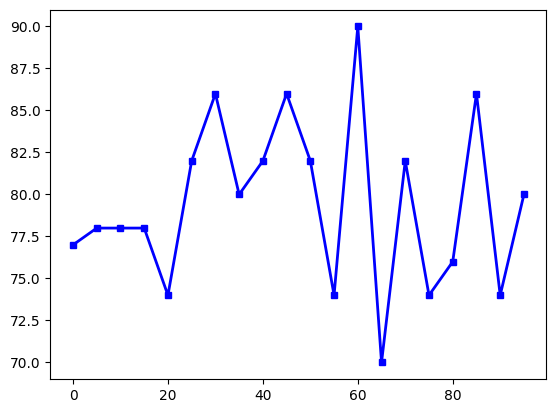

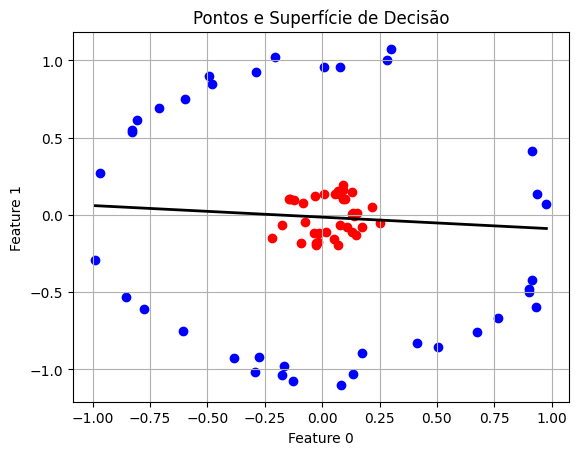

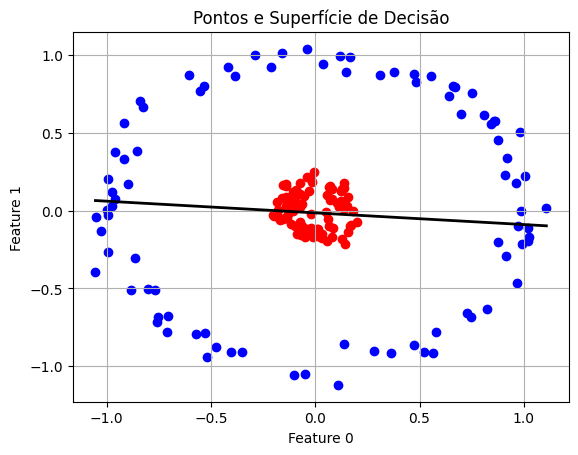

In [29]:
# Faz a plotagem dos valores e gráficos
# Começa com uma plotagem de de algumas épocas (da primeira até a última, de 5 em 5)

x_vals = list(range(0, epochs, 5))  # Pegando os índices
y_vals = [evo_erro[i] for i in x_vals]  # Pegando os valores correspondentes

# Cria o gráfico de linhas para facilitar a evolução
plt.plot(x_vals, y_vals, marker='s', linestyle='-', color='blue', linewidth=2, markersize=4)
plt.show()

# Mostra a superficie de decisão para o conjunto de treino e de teste
# Marcar como comentário para o dataset3 (não vai funcionar pela alta quantidade de dimensões)
plot_decision_boundary(dados_teste, pesos, bias)
plot_decision_boundary(dados, pesos, bias)